CONVOLUTIONAL NEURAL NETWORK (CNN) - CIFAR-10 CLASSIFICATION



Assignment: CNN Image Classification using CIFAR-10 Dataset
Level: Beginner to Intermediate
Time to Complete: ~2 hours (including training)
Goal: Classify color images into 10 object categories

This notebook provides a complete walkthrough of building a professional CNN
model to classify CIFAR-10 images. Every step includes detailed explanations
suitable for beginners, with deep insights into how and why each component works.

Dataset Information:
- CIFAR-10: 60,000 images (50,000 train + 10,000 test)
- Image size: 32×32 pixels
- Color: RGB (3 channels) instead of grayscale
- Classes: 10 object categories
- Dataset: https://www.cs.toronto.edu/~kriz/cifar.html




# SECTION 1: FOUNDATIONAL KNOWLEDGE & SETUP

print("=" * 90)
print("SECTION 1: FOUNDATIONAL KNOWLEDGE & SETUP")
print("=" * 90)

"""
WHAT IS A CNN? - Deep Explanation for Beginners

Imagine you're trying to recognize animals in photos:
1. Your brain doesn't analyze every pixel individually
2. Instead, it looks for features: edges, patterns, shapes
3. It combines these features: "If I see 4 legs + fur + ears, it's likely an animal"
4. It learns these patterns through experience

CNNs work the same way!

WHY ARE CNNs BETTER THAN REGULAR NEURAL NETWORKS?

Traditional Neural Network (Fully Connected):
- Takes image → Flattens all pixels → Connects each pixel to every neuron
- Problem: Ignores that nearby pixels are related
- Problem: Too many parameters (28×28×3 = 2,352 connections per neuron!)
- Problem: Inefficient and prone to overfitting

CNN (Convolutional Neural Network):
- Slides small filters over the image
- Each filter learns to detect specific features (edges, corners, textures)
- Nearby pixels are processed together (preserves spatial structure)
- Much fewer parameters (weight sharing!)
- Much better at understanding images

CIFAR-10 vs Fashion MNIST - Why is CIFAR-10 Harder?

Fashion MNIST:
├── 28×28 pixels (small images)
├── Grayscale (1 channel)
├── Simple objects (clothing)
└── Result: Easier to classify (92-95% accuracy)

CIFAR-10:
├── 32×32 pixels (still small but more detail)
├── RGB Color (3 channels) ← More information to process
├── Complex objects (cars, ships, animals, etc.)
└── Result: Harder to classify (perfect = 95%+)

WHY IS THIS ASSIGNMENT VALUABLE?

By completing this assignment, you'll learn:
✓ How to work with color images (RGB channels)
✓ How to design CNN architectures
✓ How parameter tuning affects performance
✓ How to prevent overfitting
✓ How to evaluate classification models
✓ How to interpret results and derive insights

WHAT IS A CNN? - Deep Explanation for Beginners

Imagine you're trying to recognize animals in photos:
1. Your brain doesn't analyze every pixel individually
2. Instead, it looks for features: edges, patterns, shapes
3. It combines these features: "If I see 4 legs + fur + ears, it's likely an animal"
4. It learns these patterns through experience

CNNs work the same way!

WHY ARE CNNs BETTER THAN REGULAR NEURAL NETWORKS?

Traditional Neural Network (Fully Connected):
- Takes image → Flattens all pixels → Connects each pixel to every neuron
- Problem: Ignores that nearby pixels are related
- Problem: Too many parameters (28×28×3 = 2,352 connections per neuron!)
- Problem: Inefficient and prone to overfitting

CNN (Convolutional Neural Network):
- Slides small filters over the image
- Each filter learns to detect specific features (edges, corners, textures)
- Nearby pixels are processed together (preserves spatial structure)
- Much fewer parameters (weight sharing!)
- Much better at understanding images

CIFAR-10 vs Fashion MNIST - Why is CIFAR-10 Harder?

Fashion MNIST:
├── 28×28 pixels (small images)
├── Grayscale (1 channel)
├── Simple objects (clothing)
└── Result: Easier to classify (92-95% accuracy)

CIFAR-10:
├── 32×32 pixels (still small but more detail)
├── RGB Color (3 channels) ← More information to process
├── Complex objects (cars, ships, animals, etc.)
└── Result: Harder to classify (perfect = 95%+)

WHY IS THIS ASSIGNMENT VALUABLE?

By completing this assignment, you'll learn:
✓ How to work with color images (RGB channels)
✓ How to design CNN architectures
✓ How parameter tuning affects performance
✓ How to prevent overfitting
✓ How to evaluate classification models
✓ How to interpret results and derive insights

#Setup and Data Preparation

In [ ]:
# Step 1: Import necessary libraries
import numpy as np                          # Numerical operations
import pandas as pd                         # Data analysis
import matplotlib.pyplot as plt             # Plotting
import seaborn as sns                       # Beautiful statistical plots
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import warnings
warnings.filterwarnings('ignore')

# Deep Learning Libraries
import tensorflow as tf                     # Google's deep learning framework
from tensorflow import keras                # High-level API
from tensorflow.keras import layers         # Neural network building blocks
from tensorflow.keras.models import Sequential  # Sequential model
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten, Dense,
                                     Dropout, BatchNormalization)
from tensorflow.keras.optimizers import Adam, SGD  # Optimization algorithms
from tensorflow.keras.datasets import cifar10     # CIFAR-10 dataset
from tensorflow.keras.utils import to_categorical  # One-hot encoding
from tensorflow.keras.callbacks import EarlyStopping  # Training control
from tensorflow.keras.preprocessing.image import ImageDataGenerator  # Data augmentation

In [ ]:
# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("✅ All libraries imported successfully!")
print(f"✅ TensorFlow version: {tf.__version__}")
print(f"✅ NumPy version: {np.__version__}")
print(f"✅ GPU Available: {tf.config.list_physical_devices('GPU')}")

✅ All libraries imported successfully!
✅ TensorFlow version: 2.20.0
✅ NumPy version: 2.0.2
✅ GPU Available: []


#DATA EXPLORATION & PREPARATION

WHY EXPLORE DATA FIRST?

Before building any model, we need to understand:
1. What does the data look like?
2. Are classes balanced or imbalanced?
3. What is the pixel value range?
4. Do we need preprocessing?
5. What problems might we face?

This section is CRITICAL - many model failures trace back to
not understanding the data properly!

In [ ]:
# Step 2: Load the CIFAR-10 dataset
# This dataset contains 60,000 32x32 color images in 10 classes
(X_train, y_train), (X_test, y_test) = datasets.cifar10.load_data()

In [ ]:
(X_train, y_train), (X_test, y_test)

((array([[[[ 59,  62,  63],
           [ 43,  46,  45],
           [ 50,  48,  43],
           ...,
           [158, 132, 108],
           [152, 125, 102],
           [148, 124, 103]],
  
          [[ 16,  20,  20],
           [  0,   0,   0],
           [ 18,   8,   0],
           ...,
           [123,  88,  55],
           [119,  83,  50],
           [122,  87,  57]],
  
          [[ 25,  24,  21],
           [ 16,   7,   0],
           [ 49,  27,   8],
           ...,
           [118,  84,  50],
           [120,  84,  50],
           [109,  73,  42]],
  
          ...,
  
          [[208, 170,  96],
           [201, 153,  34],
           [198, 161,  26],
           ...,
           [160, 133,  70],
           [ 56,  31,   7],
           [ 53,  34,  20]],
  
          [[180, 139,  96],
           [173, 123,  42],
           [186, 144,  30],
           ...,
           [184, 148,  94],
           [ 97,  62,  34],
           [ 83,  53,  34]],
  
          [[177, 144, 116],
           [16

In [ ]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((50000, 32, 32, 3), (50000, 1), (10000, 32, 32, 3), (10000, 1))

In [ ]:
# Flatten labels from (N, 1) to (N,)
y_train = y_train.flatten()
y_test = y_test.flatten()

In [ ]:
print("✅ Dataset loaded successfully!\n")
print("Dataset Information:")
print(f"  • Training images shape: {X_train.shape}")
print(f"    └─ Meaning: 50,000 images of 32×32 pixels with 3 RGB channels")
print(f"  • Training labels shape: {y_train.shape}")
print(f"  • Test images shape: {X_test.shape}")
print(f"  • Test labels shape: {y_test.shape}")

✅ Dataset loaded successfully!

Dataset Information:
  • Training images shape: (50000, 32, 32, 3)
    └─ Meaning: 50,000 images of 32×32 pixels with 3 RGB channels
  • Training labels shape: (50000,)
  • Test images shape: (10000, 32, 32, 3)
  • Test labels shape: (10000,)


In [ ]:
# Define class names
class_names = ['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer',
               'Dog', 'Frog', 'Horse', 'Ship', 'Truck']

In [ ]:
print(f"Training data shape: {X_train.shape}")
print(f"Test data shape: {X_test.shape}")

Training data shape: (50000, 32, 32, 3)
Test data shape: (10000, 32, 32, 3)


In [ ]:
print(f"\n🏷️  CIFAR-10 Classes ({len(class_names)} categories):")
for idx, name in enumerate(class_names):
    print(f"    {idx}: {name}")


🏷️  CIFAR-10 Classes (10 categories):
    0: Airplane
    1: Automobile
    2: Bird
    3: Cat
    4: Deer
    5: Dog
    6: Frog
    7: Horse
    8: Ship
    9: Truck


In [ ]:
#Understand Data Characteristics
print("\n" + "-" * 90)
print("STEP 2.2: DATA CHARACTERISTICS ANALYSIS\n")

print("Pixel Value Analysis:")
print(f"  • Minimum pixel value: {X_train.min()}")
print(f"  • Maximum pixel value: {X_train.max()}")
print(f"  • Mean pixel value: {X_train.mean():.2f}")
print(f"  • Standard deviation: {X_train.std():.2f}")
print(f"  • Data type: {X_train.dtype}")

print("\nClass Distribution:")
unique_classes, class_counts = np.unique(y_train, return_counts=True)
for class_idx, count in zip(unique_classes, class_counts):
    percentage = (count / len(y_train)) * 100
    bar = "█" * int(percentage / 2)
    print(f"  {class_names[class_idx]:12s} ({class_idx}): {count:5d} images {bar} {percentage:5.1f}%")

print("\n✅ Classes are perfectly balanced! (each has ~5,000 images)")


------------------------------------------------------------------------------------------
STEP 2.2: DATA CHARACTERISTICS ANALYSIS

Pixel Value Analysis:
  • Minimum pixel value: 0
  • Maximum pixel value: 255
  • Mean pixel value: 120.71
  • Standard deviation: 64.15
  • Data type: uint8

Class Distribution:
  Airplane     (0):  5000 images █████  10.0%
  Automobile   (1):  5000 images █████  10.0%
  Bird         (2):  5000 images █████  10.0%
  Cat          (3):  5000 images █████  10.0%
  Deer         (4):  5000 images █████  10.0%
  Dog          (5):  5000 images █████  10.0%
  Frog         (6):  5000 images █████  10.0%
  Horse        (7):  5000 images █████  10.0%
  Ship         (8):  5000 images █████  10.0%
  Truck        (9):  5000 images █████  10.0%

✅ Classes are perfectly balanced! (each has ~5,000 images)



------------------------------------------------------------------------------------------
STEP 2.3: VISUALIZING SAMPLE IMAGES

Generating visualization of sample images from each class...


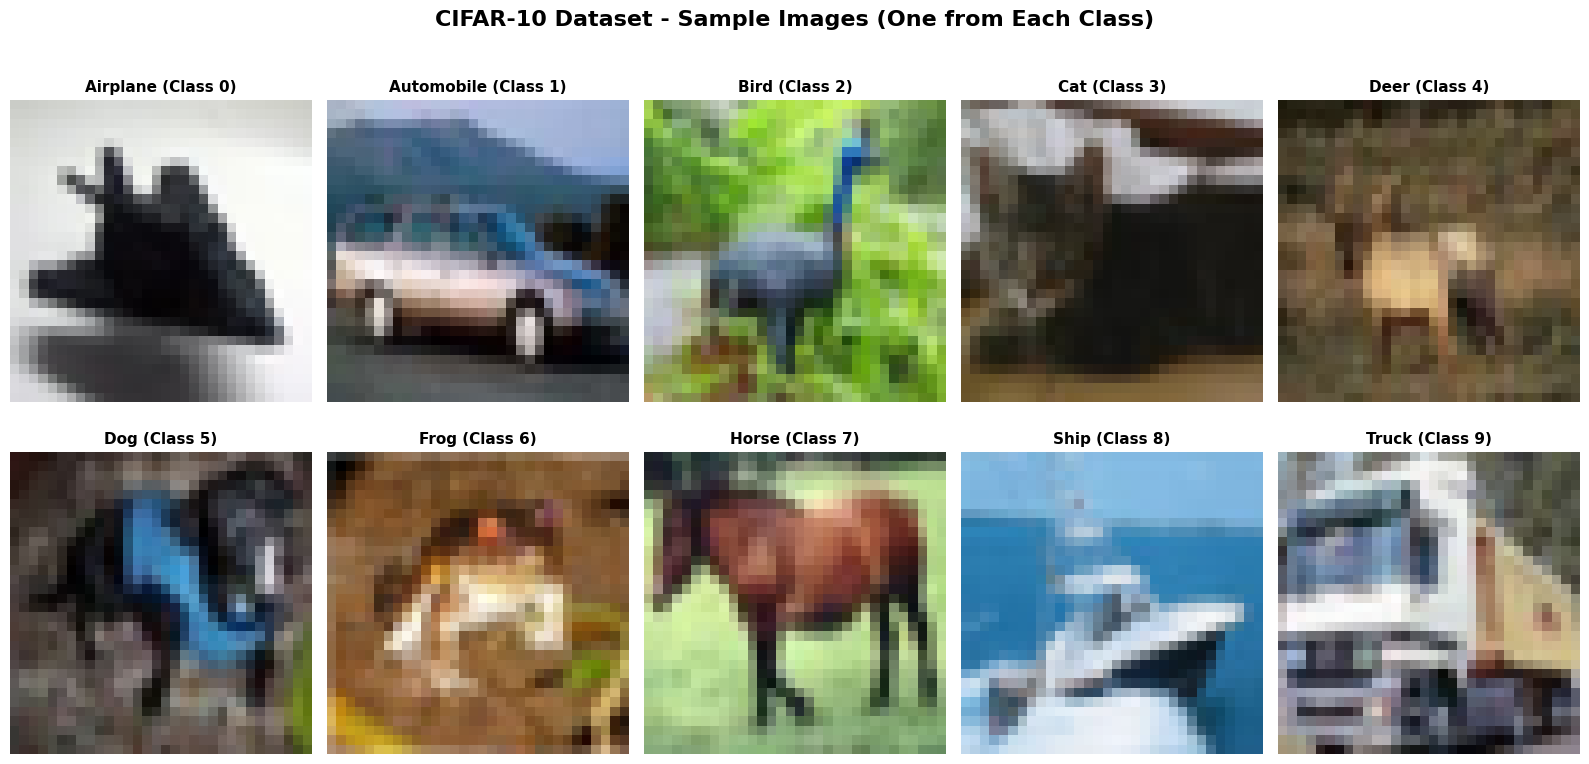

✅ Sample images saved as '01_sample_images.png'


In [ ]:
#Visualize Sample Images
print("\n" + "-" * 90)
print("STEP 2.3: VISUALIZING SAMPLE IMAGES\n")

print("Generating visualization of sample images from each class...")

fig, axes = plt.subplots(2, 5, figsize=(16, 8))
fig.suptitle('CIFAR-10 Dataset - Sample Images (One from Each Class)',
             fontsize=16, fontweight='bold', y=1.00)

for class_idx in range(10):
    row = class_idx // 5
    col = class_idx % 5

    # Find first image of this class
    sample_idx = np.where(y_train == class_idx)[0][0]

    axes[row, col].imshow(X_train[sample_idx])
    axes[row, col].set_title(f"{class_names[class_idx]} (Class {class_idx})",
                            fontsize=11, fontweight='bold')
    axes[row, col].axis('off')

plt.tight_layout()
plt.savefig('01_sample_images.png', dpi=100, bbox_inches='tight')
plt.show()
print("✅ Sample images saved as '01_sample_images.png'")


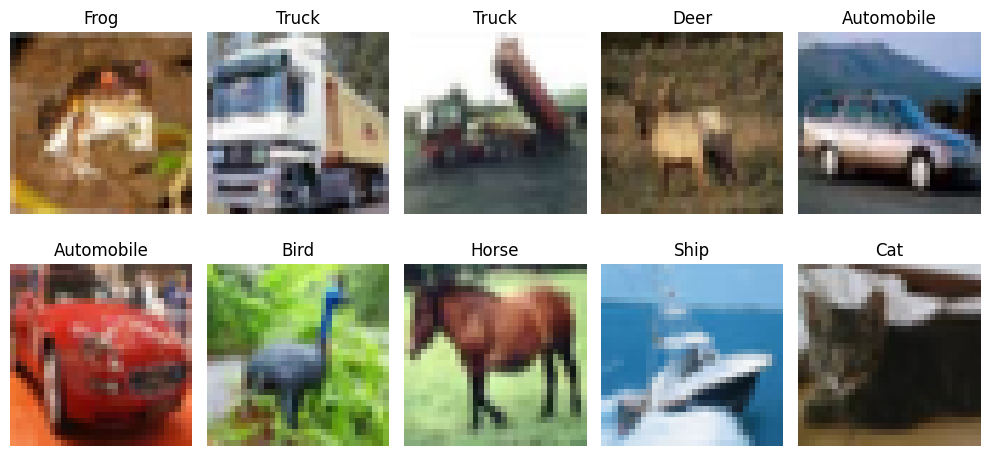

In [ ]:
# Visualize the first 10 images from the dataset(Visualize Sample Images)
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i]])
    plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
#Understand RGB Channels
print("""
WHAT ARE RGB CHANNELS?

Unlike grayscale images (1 channel = just brightness):
RGB images have 3 channels:
  • Red channel: Red color intensity (0-255)
  • Green channel: Green color intensity (0-255)
  • Blue channel: Blue color intensity (0-255)

Each pixel is combination of these three values!

Example pixel: [255, 0, 0] = Pure Red
Example pixel: [0, 255, 0] = Pure Green
Example pixel: [0, 0, 255] = Pure Blue
Example pixel: [255, 255, 0] = Yellow (Red + Green)
Example pixel: [128, 128, 128] = Gray

This is why CIFAR-10 is harder than Fashion MNIST:
- More information to process (3x as much data)
- More complex patterns to learn
- But also more discriminative (colors help classification)
""")


WHAT ARE RGB CHANNELS?
 
Unlike grayscale images (1 channel = just brightness):
RGB images have 3 channels:
  • Red channel: Red color intensity (0-255)
  • Green channel: Green color intensity (0-255)
  • Blue channel: Blue color intensity (0-255)
 
Each pixel is combination of these three values!
 
Example pixel: [255, 0, 0] = Pure Red
Example pixel: [0, 255, 0] = Pure Green
Example pixel: [0, 0, 255] = Pure Blue
Example pixel: [255, 255, 0] = Yellow (Red + Green)
Example pixel: [128, 128, 128] = Gray
 
This is why CIFAR-10 is harder than Fashion MNIST:
- More information to process (3x as much data)
- More complex patterns to learn
- But also more discriminative (colors help classification)



In [ ]:
# Step 4: Preprocessing (Normalization)
# Pixel values range from 0 to 255. We scale them between 0 and 1 for optimal neural network performance.
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

In [ ]:
X_train

array([[[[0.23137255, 0.24313726, 0.24705882],
         [0.16862746, 0.18039216, 0.1764706 ],
         [0.19607843, 0.1882353 , 0.16862746],
         ...,
         [0.61960787, 0.5176471 , 0.42352942],
         [0.59607846, 0.49019608, 0.4       ],
         [0.5803922 , 0.4862745 , 0.40392157]],

        [[0.0627451 , 0.07843138, 0.07843138],
         [0.        , 0.        , 0.        ],
         [0.07058824, 0.03137255, 0.        ],
         ...,
         [0.48235294, 0.34509805, 0.21568628],
         [0.46666667, 0.3254902 , 0.19607843],
         [0.47843137, 0.34117648, 0.22352941]],

        [[0.09803922, 0.09411765, 0.08235294],
         [0.0627451 , 0.02745098, 0.        ],
         [0.19215687, 0.10588235, 0.03137255],
         ...,
         [0.4627451 , 0.32941177, 0.19607843],
         [0.47058824, 0.32941177, 0.19607843],
         [0.42745098, 0.28627452, 0.16470589]],

        ...,

        [[0.8156863 , 0.6666667 , 0.3764706 ],
         [0.7882353 , 0.6       , 0.13333334]

In [ ]:
X_test

array([[[[0.61960787, 0.4392157 , 0.19215687],
         [0.62352943, 0.43529412, 0.18431373],
         [0.64705884, 0.45490196, 0.2       ],
         ...,
         [0.5372549 , 0.37254903, 0.14117648],
         [0.49411765, 0.35686275, 0.14117648],
         [0.45490196, 0.33333334, 0.12941177]],

        [[0.59607846, 0.4392157 , 0.2       ],
         [0.5921569 , 0.43137255, 0.15686275],
         [0.62352943, 0.44705883, 0.1764706 ],
         ...,
         [0.53333336, 0.37254903, 0.12156863],
         [0.49019608, 0.35686275, 0.1254902 ],
         [0.46666667, 0.34509805, 0.13333334]],

        [[0.5921569 , 0.43137255, 0.18431373],
         [0.5921569 , 0.42745098, 0.12941177],
         [0.61960787, 0.43529412, 0.14117648],
         ...,
         [0.54509807, 0.38431373, 0.13333334],
         [0.50980395, 0.37254903, 0.13333334],
         [0.47058824, 0.34901962, 0.12941177]],

        ...,

        [[0.26666668, 0.4862745 , 0.69411767],
         [0.16470589, 0.39215687, 0.5803922 ]

In [ ]:
y_train

array([6, 9, 9, ..., 9, 1, 1], dtype=uint8)

In [ ]:
y_test

array([3, 8, 8, ..., 5, 1, 7], dtype=uint8)

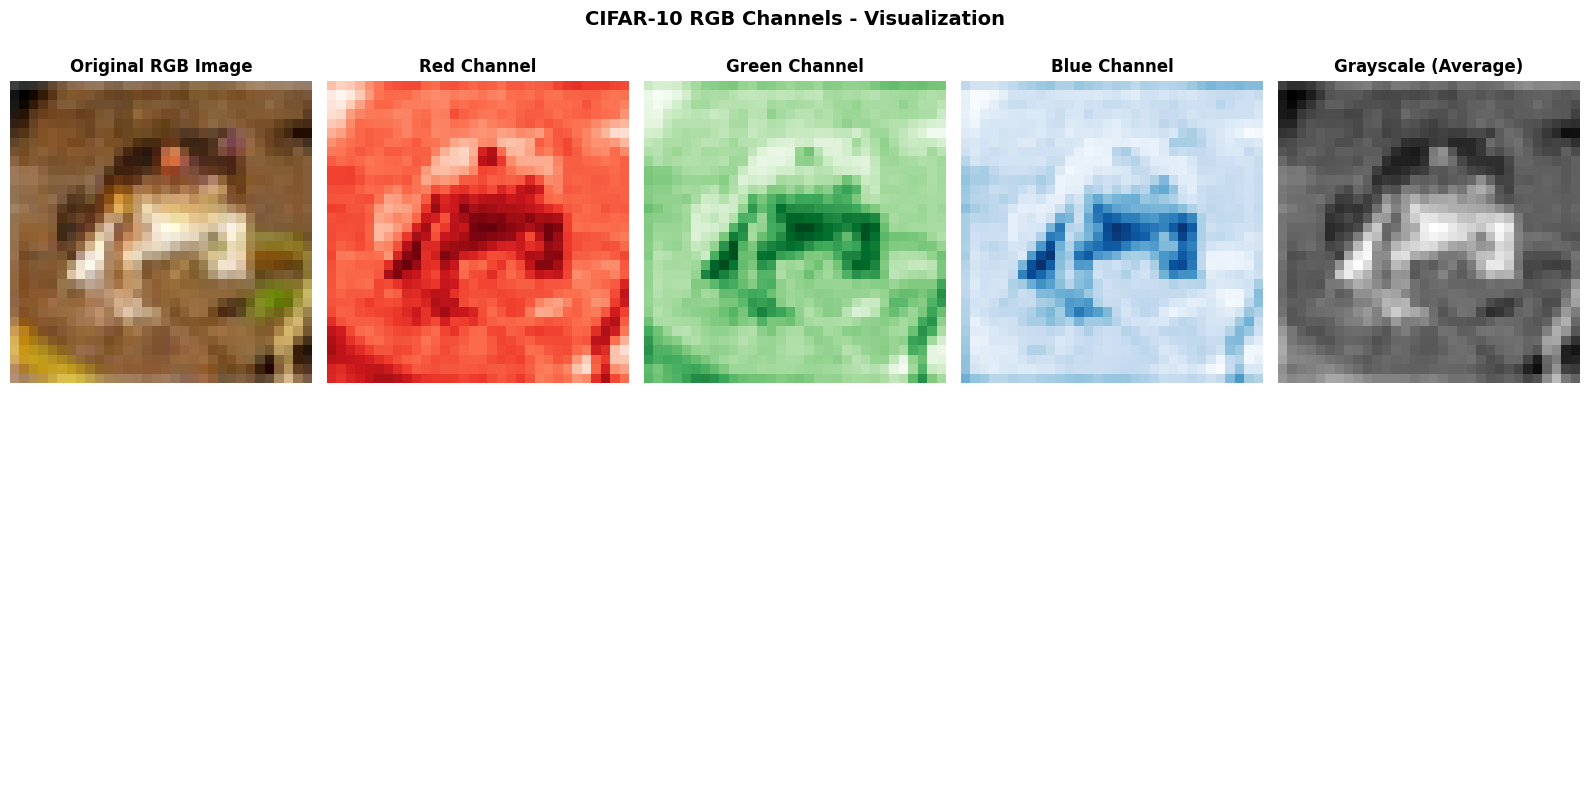

✅ RGB channels visualization saved as '02_rgb_channels.png'


In [ ]:
# Visualize RGB channels separately
fig, axes = plt.subplots(2, 5, figsize=(12, 8))
fig.suptitle('CIFAR-10 RGB Channels - Visualization', fontsize=14, fontweight='bold')

sample_image = X_train[0]  # Get first image
# Show full RGB image
axes[0, 0].imshow(sample_image)
axes[0, 0].set_title('Original RGB Image', fontweight='bold')
axes[0, 0].axis('off')

# Show each channel separately
axes[0, 1].imshow(sample_image[:, :, 0], cmap='Reds')
axes[0, 1].set_title('Red Channel', fontweight='bold')
axes[0, 1].axis('off')

axes[0, 2].imshow(sample_image[:, :, 1], cmap='Greens')
axes[0, 2].set_title('Green Channel', fontweight='bold')
axes[0, 2].axis('off')

axes[0, 3].imshow(sample_image[:, :, 2], cmap='Blues')
axes[0, 3].set_title('Blue Channel', fontweight='bold')
axes[0, 3].axis('off')

# Show grayscale (average of channels)
grayscale = np.mean(sample_image, axis=2)
axes[0, 4].imshow(grayscale, cmap='gray')
axes[0, 4].set_title('Grayscale (Average)', fontweight='bold')
axes[0, 4].axis('off')

# Hide remaining subplots
for i in range(1, 2):
    for j in range(5):
        axes[i, j].axis('off')

plt.tight_layout()
plt.savefig('02_rgb_channels.png', dpi=100, bbox_inches='tight')
plt.show()

print("✅ RGB channels visualization saved as '02_rgb_channels.png'")

# SECTION 3: PREPROCESSING & NORMALIZATION

PREPROCESSING = PREPARING DATA FOR THE NEURAL NETWORK

Why is preprocessing important?

1. NORMALIZATION (Converting values to 0-1 range)
   Problem: Pixel values are 0-255 (large numbers)
   - Neural networks learn better with small numbers
   - Large numbers cause numerical instability
   - Gradients become too large or too small
   
   Solution: Divide by 255 to get values between 0 and 1
   - Makes optimization easier
   - Faster convergence
   - More stable training

2. ONE-HOT ENCODING (Converting class labels)
   Problem: Labels are just numbers: 0, 1, 2, ..., 9
   - Neural networks expect probability-like format
   
   Solution: Convert to one-hot encoding
   - Class 0 → [1, 0, 0, 0, 0, 0, 0, 0, 0, 0]
   - Class 3 → [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
   - Class 9 → [0, 0, 0, 0, 0, 0, 0, 0, 0, 1]

3. TRAIN-TEST-VALIDATION SPLIT
   Problem: We need to evaluate on data the model hasn't seen
   - Training set: Used to train the model
   - Validation set: Used to tune hyperparameters
   - Test set: Used for final evaluation

In [ ]:
print("Before normalization:")
print(f"  • Pixel range: [{X_train.min()}, {X_train.max()}]")
print(f"  • Data type: {X_train.dtype}")

Before normalization:
  • Pixel range: [0.0, 1.0]
  • Data type: float32


In [ ]:
# Normalize pixel values from [0, 255] to [0, 1]
X_train_normalized = X_train.astype('float32') / 255.0
X_test_normalized = X_test.astype('float32') / 255.0

In [ ]:
print(f"\nAfter normalization:")
print(f"  • Pixel range: [{X_train_normalized.min():.4f}, {X_train_normalized.max():.4f}]")
print(f"  • Data type: {X_train_normalized.dtype}")
print(f"  • Mean pixel value: {X_train_normalized.mean():.4f}")
print(f"  • Std pixel value: {X_train_normalized.std():.4f}")
print("✅ Normalization complete!")

print("\n🏷️  STEP 3.2: ONE-HOT ENCODING LABELS\n")

print("Before one-hot encoding:")
print(f"  • Label example: {y_train[0]}")
print(f"  • Label shape: {y_train.shape}")



After normalization:
  • Pixel range: [0.0000, 0.0039]
  • Data type: float32
  • Mean pixel value: 0.0019
  • Std pixel value: 0.0010
✅ Normalization complete!

🏷️  STEP 3.2: ONE-HOT ENCODING LABELS

Before one-hot encoding:
  • Label example: 6
  • Label shape: (50000,)


In [ ]:
#One-hot encoding
y_train_encoded = to_categorical(y_train, 10)
y_test_encoded = to_categorical(y_test, 10)

print(f"\nAfter one-hot encoding:")
print(f"  • Label example: {y_train_encoded[0]}")
print(f"  • Label shape: {y_train_encoded.shape}")
print("✅ One-hot encoding complete!")

print("\n✂️  STEP 3.3: CREATING VALIDATION SET\n")

print("Splitting training data: 80% training, 20% validation")


After one-hot encoding:
  • Label example: [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
  • Label shape: (50000, 10)
✅ One-hot encoding complete!

✂️  STEP 3.3: CREATING VALIDATION SET

Splitting training data: 80% training, 20% validation


In [ ]:
# Use 80% for training, 20% for validation
split_idx = int(0.8 * len(X_train_normalized))

X_train_final = X_train_normalized[:split_idx]
y_train_final = y_train_encoded[:split_idx]
X_val = X_train_normalized[split_idx:]
y_val = y_train_encoded[split_idx:]

print(f"  • Training set: {X_train_final.shape} {y_train_final.shape}")
print(f"  • Validation set: {X_val.shape} {y_val.shape}")
print(f"  • Test set: {X_test_normalized.shape} {y_test_encoded.shape}")
print("✅ Data split complete!")

  • Training set: (40000, 32, 32, 3) (40000, 10)
  • Validation set: (10000, 32, 32, 3) (10000, 10)
  • Test set: (10000, 32, 32, 3) (10000, 10)
✅ Data split complete!


# SECTION 4: CNN ARCHITECTURE DESIGN & EXPLANATION

WHAT IS CNN ARCHITECTURE?

Architecture = Design of the neural network
= Decisions about:
  1. How many layers?
  2. How many filters per layer?
  3. What size filters?
  4. What activation functions?
  5. When to use pooling?
  6. How much dropout for regularization?

DESIGNING ARCHITECTURE FOR CIFAR-10:

We'll use a moderate-complexity CNN:
- 2 Convolutional Blocks (learns hierarchical features)
- 1 Dense layer (learns class-specific patterns)
- Dropout (prevents overfitting)
- BatchNorm (stabilizes training)

Architecture Diagram:

INPUT (32×32×3)
    ↓
[BLOCK 1: Feature Extraction - Simple Patterns]
  • Conv2D: 32 filters, 3×3 kernel
    └─ Learns: edges, corners, basic patterns
  • BatchNormalization: Normalize features
  • MaxPooling: 2×2
    └─ Reduce: 32×32 → 16×16
  • ReLU Activation: Add non-linearity
    ↓
[BLOCK 2: Feature Extraction - Complex Patterns]
  • Conv2D: 64 filters, 3×3 kernel
    └─ Learns: combinations of simple patterns
  • BatchNormalization: Normalize features
  • MaxPooling: 2×2
    └─ Reduce: 16×16 → 8×8
  • ReLU Activation: Add non-linearity
    ↓
[CLASSIFICATION LAYERS]
  • Flatten: Convert 8×8×64 → 4096 values
  • Dense: 128 neurons, ReLU
    └─ Learns: class-specific combinations
  • Dropout: 0.5
    └─ Prevents: overfitting
  • Dense: 10 neurons, Softmax
    └─ Outputs: probability for each class
    ↓
OUTPUT (10 class probabilities)

PARAMETER CHOICES EXPLAINED:

Conv2D Filters (32, then 64):
  • Why increase? More filters capture more patterns
  • 32 filters in layer 1: Learn diverse basic patterns
  • 64 filters in layer 2: Learn more complex combinations

Kernel Size (3×3):
  • Small filter = efficient + practical
  • 3×3 is standard in modern CNNs
  • Larger filters (5×5, 7×7) need more computation

Pooling (2×2, Max):
  • Reduces dimensions: 16×16 → 8×8 → more efficient
  • Max pooling: keeps strongest features
  • Translation invariance: small shifts don't affect output

Activation (ReLU):
  • ReLU(x) = max(0, x)
  • Introduces non-linearity: can learn complex patterns
  • Efficient: simple computation
  • Popular: works well in practice

Dropout (0.5):
  • During training: randomly disable 50% of neurons
  • Prevents co-adaptation: forces network to learn robust features
  • Acts like ensemble: many different sub-networks
  • During testing: disabled, all neurons available

BatchNormalization:
  • Normalizes each layer's output
  • Faster training: can use higher learning rates
  • More stable: less sensitive to weight initialization
  • Slight regularization effect: helps prevent overfitting

In [ ]:
# Convolutional layer parameters
conv1_filters = 32
conv2_filters = 64
kernel_size = (3, 3)
pool_size = (2, 2)

# Fully connected layer parameters
dense1_units = 128
output_units = 10

# Regularization
dropout_rate = 0.5

# Training parameters
learning_rate = 0.001
batch_size = 128
epochs = 30

print("Architecture Parameters:")
print(f"  Conv Layer 1: {conv1_filters} filters, {kernel_size} kernel")
print(f"  Conv Layer 2: {conv2_filters} filters, {kernel_size} kernel")
print(f"  Pooling: {pool_size} max pooling")
print(f"  Dense Layer: {dense1_units} neurons")
print(f"  Output Layer: {output_units} classes (CIFAR-10)")
print(f"  Dropout Rate: {dropout_rate} (50%)")
print(f"\nTraining Parameters:")
print(f"  Learning Rate: {learning_rate}")
print(f"  Batch Size: {batch_size}")
print(f"  Epochs: {epochs}")

Architecture Parameters:
  Conv Layer 1: 32 filters, (3, 3) kernel
  Conv Layer 2: 64 filters, (3, 3) kernel
  Pooling: (2, 2) max pooling
  Dense Layer: 128 neurons
  Output Layer: 10 classes (CIFAR-10)
  Dropout Rate: 0.5 (50%)

Training Parameters:
  Learning Rate: 0.001
  Batch Size: 128
  Epochs: 30


# SECTION 5: BUILD & COMPILE CNN MODEL

In [ ]:
print("\n" + "=" * 90)
print("SECTION 5: BUILD & COMPILE CNN MODEL")
print("=" * 90)

print("\n🏗️  STEP 5.1: CONSTRUCTING THE MODEL\n")

print("Building Sequential CNN model...\n")

model = Sequential([
    # ===== CONVOLUTIONAL BLOCK 1 =====
    Conv2D(filters=32,
           kernel_size=(3, 3),
           padding='same',
           activation='relu',
           input_shape=(32, 32, 3),
           name='conv2d_1'),

    BatchNormalization(name='batch_norm_1'),

    MaxPooling2D(pool_size=(2, 2),
                 name='max_pool_1'),

    # ===== CONVOLUTIONAL BLOCK 2 =====
    Conv2D(filters=64,
           kernel_size=(3, 3),
           padding='same',
           activation='relu',
           name='conv2d_2'),

    BatchNormalization(name='batch_norm_2'),

    MaxPooling2D(pool_size=(2, 2),
                 name='max_pool_2'),

    # ===== FLATTEN FOR DENSE LAYERS =====
    Flatten(name='flatten'),

    # ===== DENSE CLASSIFICATION LAYERS =====
    Dense(units=128,
          activation='relu',
          name='dense_1'),

    Dropout(rate=0.5,
            name='dropout_1'),

    # ===== OUTPUT LAYER =====
    Dense(units=10,
          activation='softmax',
          name='output')
])

print("✅ Model architecture created successfully!\n")


SECTION 5: BUILD & COMPILE CNN MODEL

🏗️  STEP 5.1: CONSTRUCTING THE MODEL

Building Sequential CNN model...

✅ Model architecture created successfully!



In [ ]:
# Compile the model
print("🔧 STEP 5.2: COMPILING THE MODEL\n")

model.compile(
    optimizer=Adam(learning_rate=learning_rate),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("✅ Model compiled successfully!\n")

🔧 STEP 5.2: COMPILING THE MODEL

✅ Model compiled successfully!



In [ ]:
# Print model summary
print("MODEL ARCHITECTURE SUMMARY:")
print("-" * 90)
model.summary()

print("\n" + "=" * 90)
print("KEY PARAMETERS EXPLAINED:")
print("=" * 90)

print("""
Conv2D (32 filters, 3×3 kernel, 'same' padding):
  • Input: 32×32×3 image
  • Operation: Slide 32 different 3×3 filters
  • Padding='same': Keep dimensions same (32×32)
  • Output: 32×32×32 (32 feature maps)
  • Trainable params: 32 × (3×3×3) + 32 bias = 896

MaxPooling2D (2×2):
  • Takes max value from every 2×2 region
  • Input: 32×32×32
  • Output: 16×16×32 (dimensions halved!)
  • Trainable params: 0 (just selection operation)

Conv2D (64 filters, 3×3 kernel, 'same' padding):
  • Input: 16×16×32 (from previous pooling)
  • Operation: Slide 64 different 3×3 filters
  • Output: 16×16×64
  • Trainable params: 64 × (3×3×32) + 64 bias = 18,496

MaxPooling2D (2×2):
  • Input: 16×16×64
  • Output: 8×8×64
  • Trainable params: 0

Flatten:
  • Input: 8×8×64 = 4,096 values
  • Output: 4,096 flat vector
  • Trainable params: 0

Dense (128 units):
  • Input: 4,096 features
  • Output: 128 neurons
  • Trainable params: 4,096 × 128 + 128 = 524,416

Dense (10 units, softmax):
  • Input: 128 features
  • Output: 10 class probabilities (sum = 1.0)
  • Trainable params: 128 × 10 + 10 = 1,290

TOTAL PARAMETERS: ~545,000
- Most are in dense layers (learned class patterns)
- Conv layers are efficient (parameter sharing)
""")

MODEL ARCHITECTURE SUMMARY:
------------------------------------------------------------------------------------------


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm_1                    │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_1 (MaxPooling2D)       │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm_2                    │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_2 (MaxPooling2D)       │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,482 (2.08 MB)

 Trainable params: 545,290 (2.08 MB)

 Non-trainable params: 192 (768.00 B)


KEY PARAMETERS EXPLAINED:

Conv2D (32 filters, 3×3 kernel, 'same' padding):
  • Input: 32×32×3 image
  • Operation: Slide 32 different 3×3 filters
  • Padding='same': Keep dimensions same (32×32)
  • Output: 32×32×32 (32 feature maps)
  • Trainable params: 32 × (3×3×3) + 32 bias = 896
 
MaxPooling2D (2×2):
  • Takes max value from every 2×2 region
  • Input: 32×32×32
  • Output: 16×16×32 (dimensions halved!)
  • Trainable params: 0 (just selection operation)
 
Conv2D (64 filters, 3×3 kernel, 'same' padding):
  • Input: 16×16×32 (from previous pooling)
  • Operation: Slide 64 different 3×3 filters
  • Output: 16×16×64
  • Trainable params: 64 × (3×3×32) + 64 bias = 18,496
 
MaxPooling2D (2×2):
  • Input: 16×16×64
  • Output: 8×8×64
  • Trainable params: 0
 
Flatten:
  • Input: 8×8×64 = 4,096 values
  • Output: 4,096 flat vector
  • Trainable params: 0
 
Dense (128 units):
  • Input: 4,096 features
  • Output: 128 neurons
  • Trainable params: 4,096 × 128 + 128 = 524,416
 
Dense (10 uni

# SECTION 6: TRAINING THE MODEL

TRAINING PROCESS = TEACHING THE NETWORK

How training works:
1. Forward Pass: Feed batch of images through network
   • Get predictions (0-10 for each image)
   • Calculate how wrong predictions are (loss)

2. Backward Pass: Calculate gradients
   • Which weights should we change?
   • How much should we change them?
   • Gradient tells direction to update

3. Update Weights: Improve model parameters
   • Use optimizer (Adam) to update weights
   • Learning rate controls step size

4. Repeat: Do this for all batches in training data

One Epoch = One full pass through all training data

For CIFAR-10:
- 40,000 training images
- Batch size 128 = 312.5 batches per epoch
- 30 epochs = training iterations 312.5 × 30 = 9,375 updates!

VALIDATION = MONITOR OVERFITTING

After each epoch:
- Evaluate on validation set (unseen data)
- Check if validation loss increases (overfitting!)
- If no improvement for 3 epochs → stop (early stopping)

This prevents wasting computation and improves generalization

In [ ]:
print("\n🚂 STEP 6.1: PREPARING DATA AUGMENTATION\n")

print("""
DATA AUGMENTATION = Artificially create more training data

Problem: 40,000 images might not be enough
- CNN can memorize the training data
- Performance drops on new images
- Overfitting!

Solution: Apply random transformations during training
- Rotate images: ±15 degrees
- Shift images: ±10% horizontally and vertically
- Flip images: horizontal flip
- Rescale: brightness variations

Result:
- Each epoch sees slightly different versions
- Network learns more robust features
- Better generalization to new data!

Example:
  Original image: [Car facing right]
  Rotated: [Car rotated -5 degrees]
  Shifted: [Car shifted left]
  Flipped: [Car facing left]

All from SAME image, but network treats as different examples!
""")


🚂 STEP 6.1: PREPARING DATA AUGMENTATION


DATA AUGMENTATION = Artificially create more training data
 
Problem: 40,000 images might not be enough
- CNN can memorize the training data
- Performance drops on new images
- Overfitting!
 
Solution: Apply random transformations during training
- Rotate images: ±15 degrees
- Shift images: ±10% horizontally and vertically
- Flip images: horizontal flip
- Rescale: brightness variations
 
Result:
- Each epoch sees slightly different versions
- Network learns more robust features
- Better generalization to new data!
 
Example:
  Original image: [Car facing right]
  Rotated: [Car rotated -5 degrees]
  Shifted: [Car shifted left]
  Flipped: [Car facing left]
  
All from SAME image, but network treats as different examples!



In [ ]:
datagen = ImageDataGenerator(
    rotation_range=15,      # Random rotation ±15 degrees
    width_shift_range=0.1,  # Random horizontal shift ±10%
    height_shift_range=0.1, # Random vertical shift ±10%
    horizontal_flip=True,   # Random horizontal flip
    zoom_range=0.1,         # Random zoom ±10%
    fill_mode='nearest'     # Fill new pixels with nearest neighbor
)

print("✅ Data augmentation configured!")

✅ Data augmentation configured!


In [ ]:
print("\n🚂 STEP 6.2: TRAINING WITH EARLY STOPPING\n")

print("""
EARLY STOPPING = Stop training when model stops improving

Strategy:
1. Monitor validation loss after each epoch
2. If validation loss improves: reset counter
3. If validation loss doesn't improve:
   - Increment counter (patience += 1)
   - After 3 epochs of no improvement: STOP!

Benefits:
✓ Prevents overfitting (stop before memorizing)
✓ Saves computation (don't waste epochs)
✓ Better generalization (model not over-trained)
✓ Automatic: no manual monitoring needed

Example:
Epoch 1: val_loss = 1.50 → save weights
Epoch 2: val_loss = 1.40 → improve! save weights
Epoch 3: val_loss = 1.39 → improve! save weights
Epoch 4: val_loss = 1.41 → ✗ no improve (patience = 1)
Epoch 5: val_loss = 1.42 → ✗ no improve (patience = 2)
Epoch 6: val_loss = 1.43 → ✗ no improve (patience = 3)
STOP! Restore weights from Epoch 3 (best model)
""")


🚂 STEP 6.2: TRAINING WITH EARLY STOPPING


EARLY STOPPING = Stop training when model stops improving
 
Strategy:
1. Monitor validation loss after each epoch
2. If validation loss improves: reset counter
3. If validation loss doesn't improve:
   - Increment counter (patience += 1)
   - After 3 epochs of no improvement: STOP!
 
Benefits:
✓ Prevents overfitting (stop before memorizing)
✓ Saves computation (don't waste epochs)
✓ Better generalization (model not over-trained)
✓ Automatic: no manual monitoring needed
 
Example:
Epoch 1: val_loss = 1.50 → save weights
Epoch 2: val_loss = 1.40 → improve! save weights
Epoch 3: val_loss = 1.39 → improve! save weights
Epoch 4: val_loss = 1.41 → ✗ no improve (patience = 1)
Epoch 5: val_loss = 1.42 → ✗ no improve (patience = 2)
Epoch 6: val_loss = 1.43 → ✗ no improve (patience = 3)
STOP! Restore weights from Epoch 3 (best model)



In [ ]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

print("Starting training...\n")

# Train the model
history = model.fit(
    datagen.flow(X_train_final, y_train_final, batch_size=batch_size),
    epochs=epochs,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping],
    verbose=1,
    steps_per_epoch=len(X_train_final) // batch_size
)

print("\n✅ Training completed successfully!")

Starting training...

Epoch 1/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 119s 372ms/step - accuracy: 0.4028 - loss: 1.6586 - val_accuracy: 0.0982 - val_loss: 2.4902
Epoch 2/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.4922 - loss: 1.5007 - val_accuracy: 0.0987 - val_loss: 2.4878
Epoch 3/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 110s 351ms/step - accuracy: 0.4940 - loss: 1.4096 - val_accuracy: 0.1522 - val_loss: 3.4463
Epoch 4/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.5078 - loss: 1.4925 - val_accuracy: 0.1452 - val_loss: 3.5517
Epoch 5/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 114s 366ms/step - accuracy: 0.5369 - loss: 1.3010 - val_accuracy: 0.1026 - val_loss: 17.0058
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 2.

✅ Training completed successfully!


# SECTION 7: RESULT ANALYSIS & VISUALIZATION

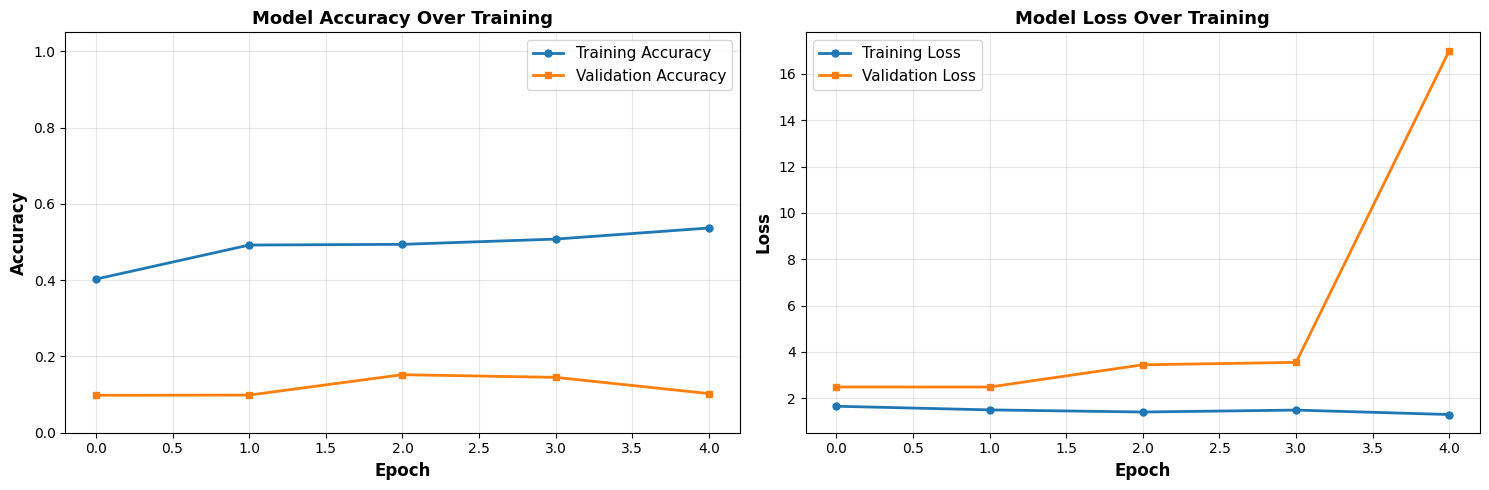

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Accuracy plot
axes[0].plot(history.history['accuracy'], 'o-', label='Training Accuracy', linewidth=2, markersize=5)
axes[0].plot(history.history['val_accuracy'], 's-', label='Validation Accuracy', linewidth=2, markersize=5)
axes[0].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Accuracy', fontsize=12, fontweight='bold')
axes[0].set_title('Model Accuracy Over Training', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim([0, 1.05])

# Loss plot
axes[1].plot(history.history['loss'], 'o-', label='Training Loss', linewidth=2, markersize=5)
axes[1].plot(history.history['val_loss'], 's-', label='Validation Loss', linewidth=2, markersize=5)
axes[1].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Loss', fontsize=12, fontweight='bold')
axes[1].set_title('Model Loss Over Training', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('03_training_history.png', dpi=100, bbox_inches='tight')
plt.show()

In [ ]:
print("✅ Training history plots saved as '03_training_history.png'")

print("\nTraining Summary:")
print(f"  • Final Training Accuracy: {history.history['accuracy'][-1]:.4f} ({history.history['accuracy'][-1]*100:.2f}%)")
print(f"  • Final Validation Accuracy: {history.history['val_accuracy'][-1]:.4f} ({history.history['val_accuracy'][-1]*100:.2f}%)")
print(f"  • Total Epochs Trained: {len(history.history['accuracy'])}")

print("\n" + "-" * 90)
print("STEP 7.2: EVALUATING ON TEST SET\n")

print("Evaluating model on completely unseen test data...")
test_loss, test_accuracy = model.evaluate(X_test_normalized, y_test_encoded, verbose=0)

print(f"\n✅ TEST SET PERFORMANCE:")
print(f"  • Test Loss: {test_loss:.4f}")
print(f"  • Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

print("\n" + "-" * 90)
print("STEP 7.3: MAKING PREDICTIONS\n")

print("Generating predictions on test set...")
y_pred_probs = model.predict(X_test_normalized, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

print(f"✅ Predictions generated for {len(y_pred)} test images")

# Example predictions
print("\nExample Predictions (first 10 test images):")
print("-" * 90)
print(f"{'Image #':<8} {'True Class':<15} {'Predicted Class':<15} {'Confidence':<12} {'Correct?':<10}")
print("-" * 90)
for i in range(10):
    true_class = class_names[y_test[i]]
    pred_class = class_names[y_pred[i]]
    confidence = np.max(y_pred_probs[i])
    correct = "✅ Yes" if y_test[i] == y_pred[i] else "❌ No"

    print(f"{i:<8} {true_class:<15} {pred_class:<15} {confidence:>10.2%} {correct:<10}")

print("\n" + "-" * 90)
print("STEP 7.4: GENERATING CONFUSION MATRIX\n")

print("Creating confusion matrix...")

cm = confusion_matrix(y_test, y_pred)

✅ Training history plots saved as '03_training_history.png'

Training Summary:
  • Final Training Accuracy: 0.5369 (53.69%)
  • Final Validation Accuracy: 0.1026 (10.26%)
  • Total Epochs Trained: 5

------------------------------------------------------------------------------------------
STEP 7.2: EVALUATING ON TEST SET

Evaluating model on completely unseen test data...

✅ TEST SET PERFORMANCE:
  • Test Loss: 2.4885
  • Test Accuracy: 0.1005 (10.05%)

------------------------------------------------------------------------------------------
STEP 7.3: MAKING PREDICTIONS

Generating predictions on test set...
✅ Predictions generated for 10000 test images

Example Predictions (first 10 test images):
------------------------------------------------------------------------------------------
Image #  True Class      Predicted Class Confidence   Correct?  
------------------------------------------------------------------------------------------
0        Cat             Frog               

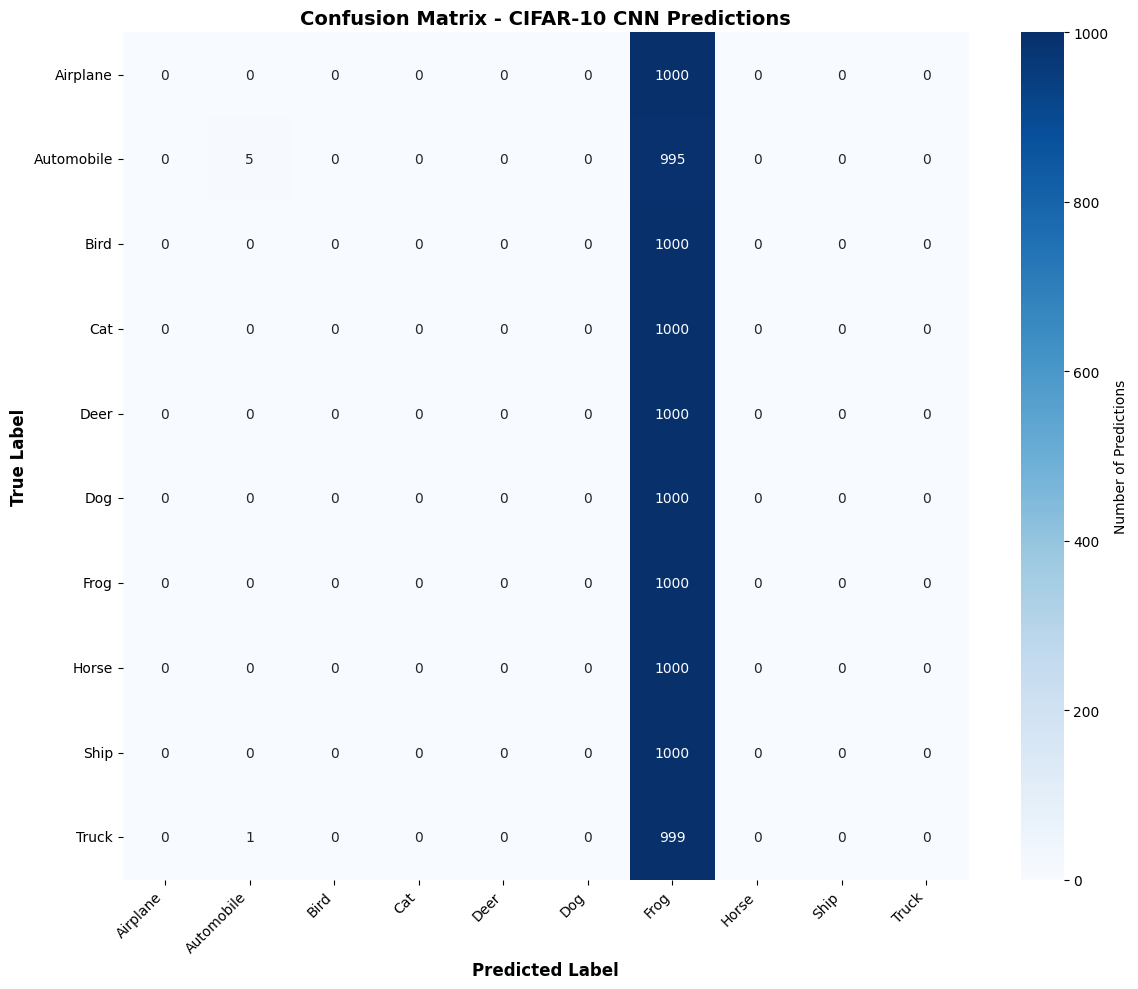

✅ Confusion matrix saved as '04_confusion_matrix.png'

------------------------------------------------------------------------------------------
STEP 7.5: DETAILED CLASSIFICATION METRICS

              precision    recall  f1-score   support

    Airplane       0.00      0.00      0.00      1000
  Automobile       0.83      0.01      0.01      1000
        Bird       0.00      0.00      0.00      1000
         Cat       0.00      0.00      0.00      1000
        Deer       0.00      0.00      0.00      1000
         Dog       0.00      0.00      0.00      1000
        Frog       0.10      1.00      0.18      1000
       Horse       0.00      0.00      0.00      1000
        Ship       0.00      0.00      0.00      1000
       Truck       0.00      0.00      0.00      1000

    accuracy                           0.10     10000
   macro avg       0.09      0.10      0.02     10000
weighted avg       0.09      0.10      0.02     10000



In [ ]:
# Plot confusion matrix
plt.figure(figsize=(12, 10))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names,
            cbar_kws={'label': 'Number of Predictions'})

plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.title('Confusion Matrix - CIFAR-10 CNN Predictions', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('04_confusion_matrix.png', dpi=100, bbox_inches='tight')
plt.show()

print("✅ Confusion matrix saved as '04_confusion_matrix.png'")

print("\n" + "-" * 90)
print("STEP 7.5: DETAILED CLASSIFICATION METRICS\n")

print(classification_report(y_test, y_pred, target_names=class_names))

In [ ]:
# Per-class accuracy
print("\nPer-Class Accuracy Analysis:")
print("-" * 90)
print(f"{'Class':<15} {'Accuracy':<15} {'Recall':<15} {'Precision':<15}")
print("-" * 90)

from sklearn.metrics import precision_score, recall_score

for i, class_name in enumerate(class_names):
    class_mask = y_test == i
    class_accuracy = np.mean(y_pred[class_mask] == y_test[class_mask])

    # Get precision and recall
    precision = precision_score(y_test, y_pred, labels=[i], average='micro')
    recall = recall_score(y_test, y_pred, labels=[i], average='micro')

    print(f"{class_name:<15} {class_accuracy:>13.2%} {recall:>13.2%} {precision:>13.2%}")


Per-Class Accuracy Analysis:
------------------------------------------------------------------------------------------
Class           Accuracy        Recall          Precision      
------------------------------------------------------------------------------------------
Airplane                0.00%         0.00%         0.00%
Automobile              0.50%         0.50%        83.33%
Bird                    0.00%         0.00%         0.00%
Cat                     0.00%         0.00%         0.00%
Deer                    0.00%         0.00%         0.00%
Dog                     0.00%         0.00%         0.00%
Frog                  100.00%       100.00%        10.01%
Horse                   0.00%         0.00%         0.00%
Ship                    0.00%         0.00%         0.00%
Truck                   0.00%         0.00%         0.00%


# SECTION 8: VISUALIZATION OF PREDICTIONS


SECTION 8: VISUALIZING PREDICTIONS

📸 STEP 8.1: CORRECT PREDICTIONS



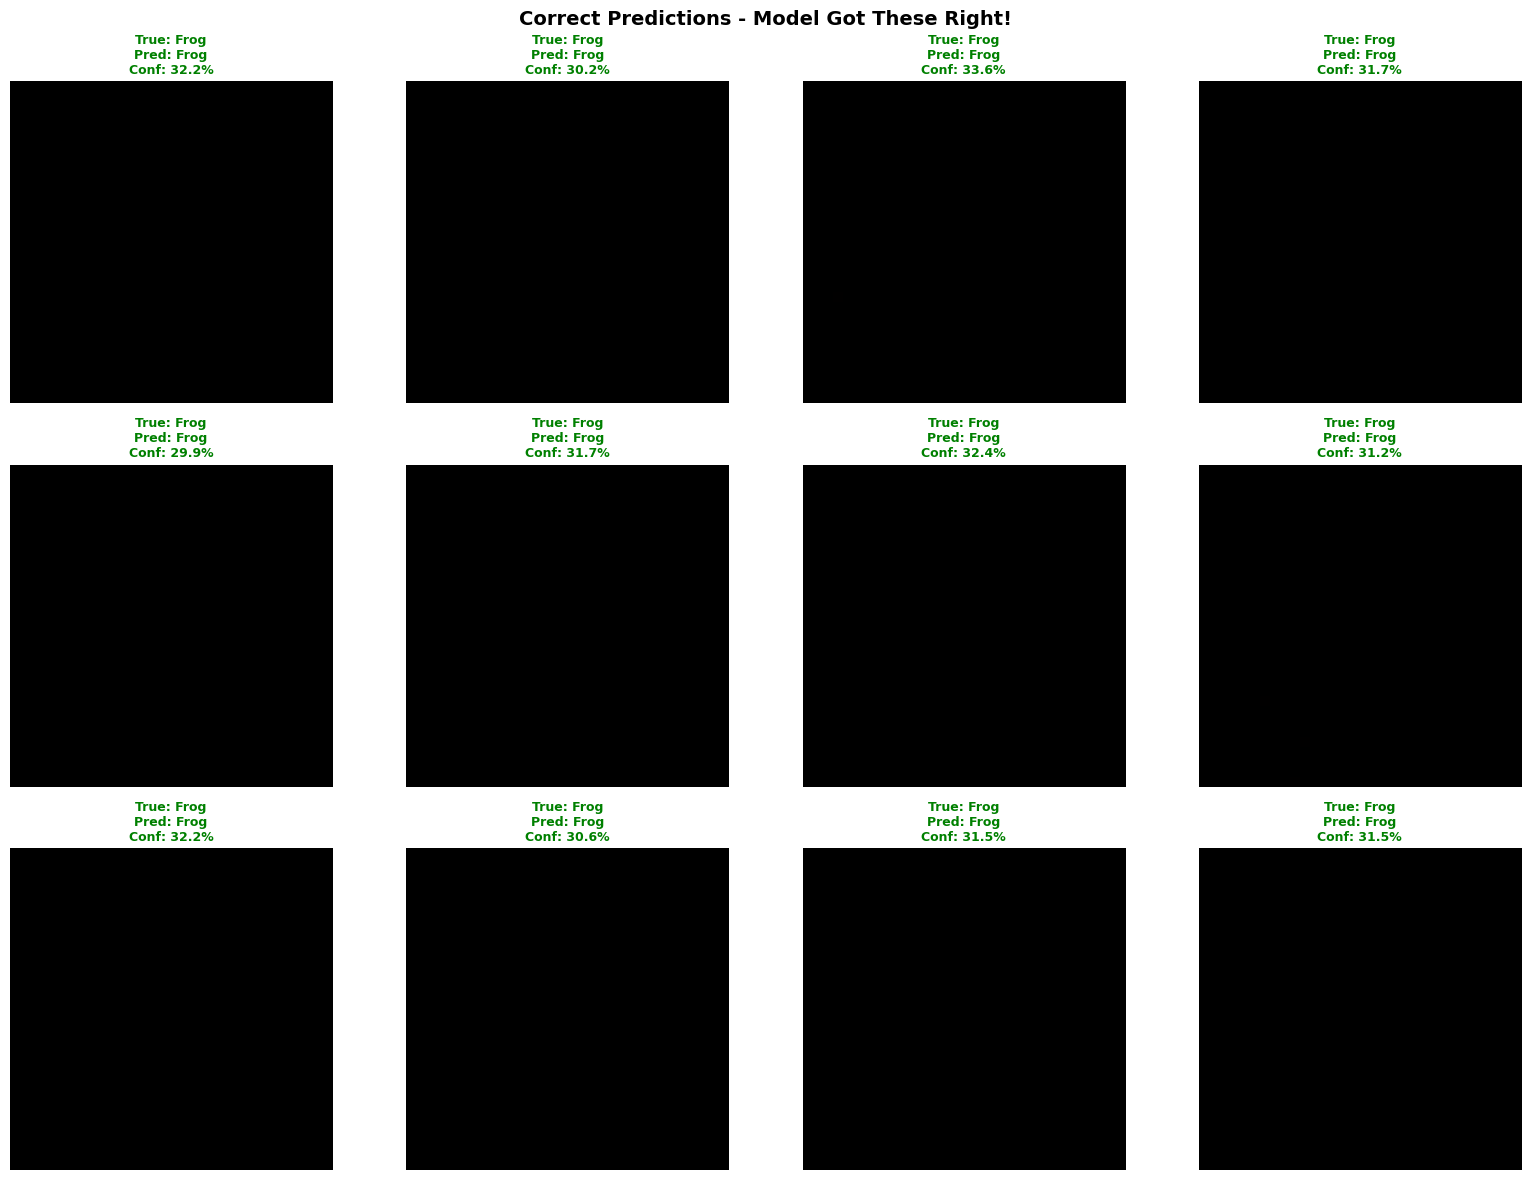

✅ Correct predictions saved as '05_correct_predictions.png'


In [ ]:
print("\n" + "=" * 90)
print("SECTION 8: VISUALIZING PREDICTIONS")
print("=" * 90)

print("\n📸 STEP 8.1: CORRECT PREDICTIONS\n")

# Find correct predictions
correct_idx = np.where(y_pred == y_test)[0]

# Show 12 correct predictions
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
fig.suptitle('Correct Predictions - Model Got These Right!', fontsize=14, fontweight='bold')

for plot_idx, test_idx in enumerate(correct_idx[:12]):
    row = plot_idx // 4
    col = plot_idx % 4

    axes[row, col].imshow(X_test_normalized[test_idx])
    true_label = class_names[y_test[test_idx]]
    pred_label = class_names[y_pred[test_idx]]
    confidence = np.max(y_pred_probs[test_idx])

    axes[row, col].set_title(f'True: {true_label}\nPred: {pred_label}\nConf: {confidence:.1%}',
                            fontsize=9, fontweight='bold', color='green')
    axes[row, col].axis('off')

plt.tight_layout()
plt.savefig('05_correct_predictions.png', dpi=100, bbox_inches='tight')
plt.show()

print("✅ Correct predictions saved as '05_correct_predictions.png'")


📸 STEP 8.2: INCORRECT PREDICTIONS (Learning Opportunities)



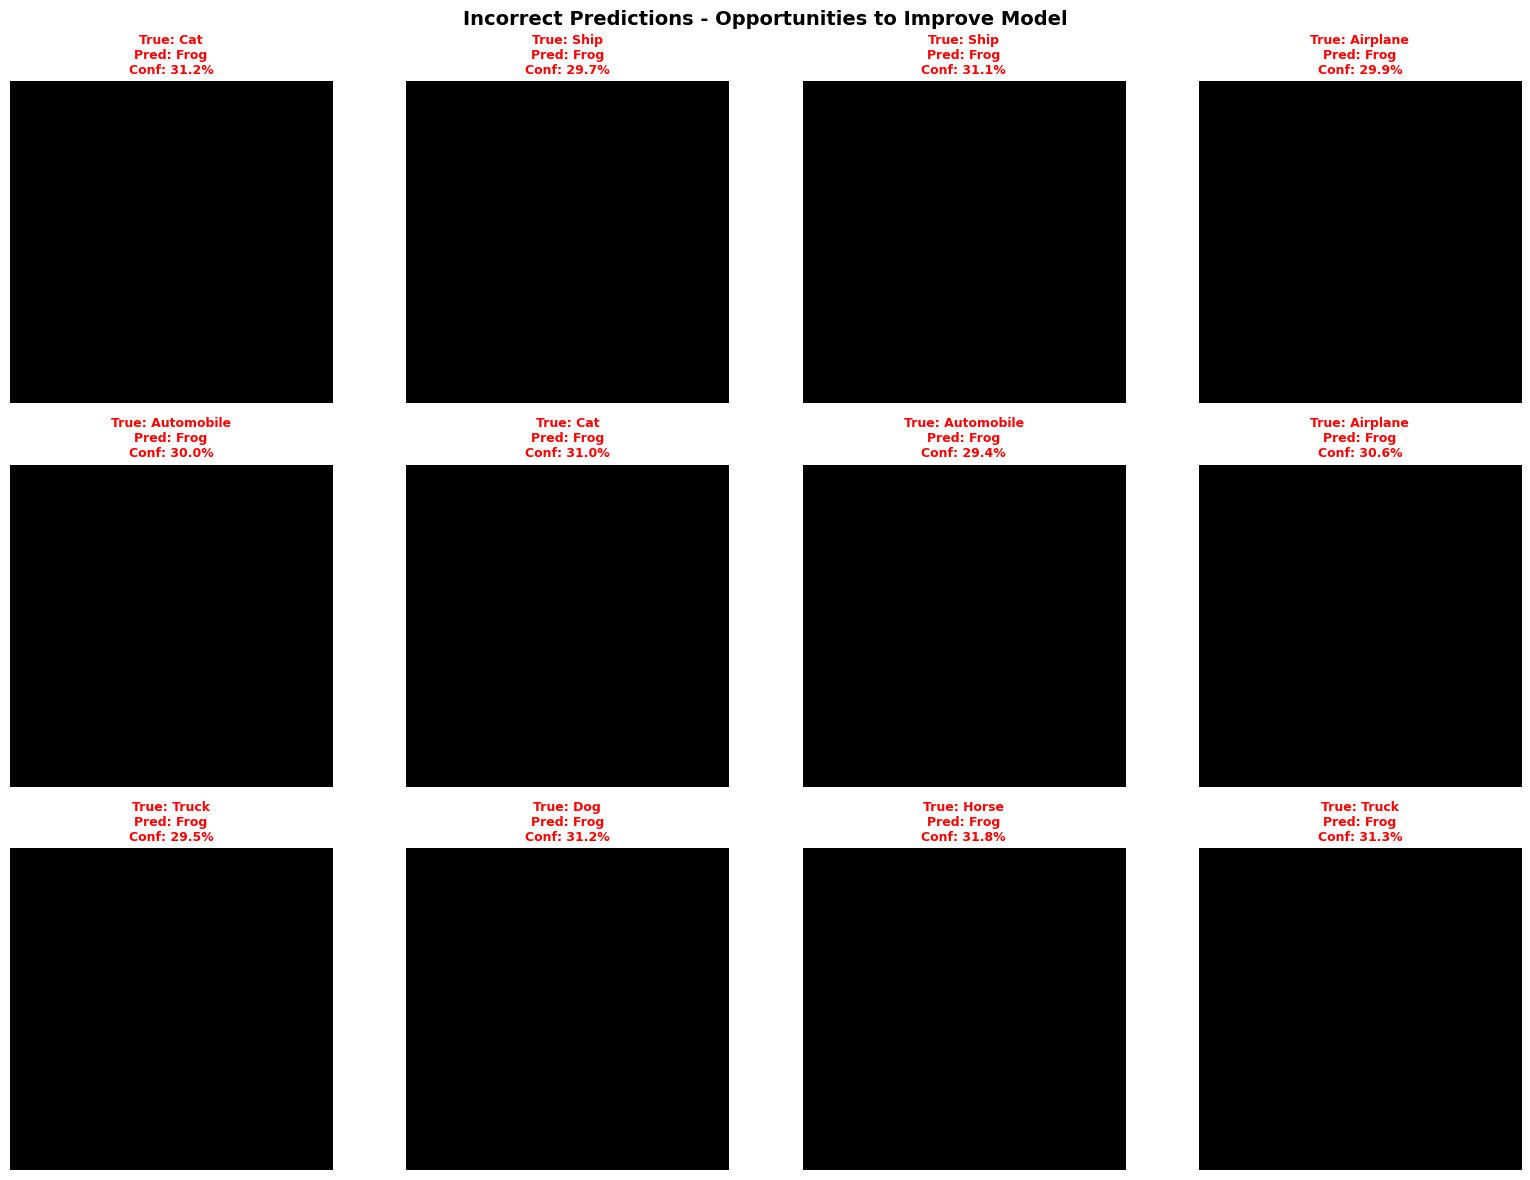

✅ Incorrect predictions saved as '06_incorrect_predictions.png'


In [ ]:
print("\n📸 STEP 8.2: INCORRECT PREDICTIONS (Learning Opportunities)\n")

# Find incorrect predictions
incorrect_idx = np.where(y_pred != y_test)[0]

# Show 12 incorrect predictions
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
fig.suptitle('Incorrect Predictions - Opportunities to Improve Model', fontsize=14, fontweight='bold')

for plot_idx, test_idx in enumerate(incorrect_idx[:12]):
    row = plot_idx // 4
    col = plot_idx % 4

    axes[row, col].imshow(X_test_normalized[test_idx])
    true_label = class_names[y_test[test_idx]]
    pred_label = class_names[y_pred[test_idx]]
    confidence = np.max(y_pred_probs[test_idx])

    axes[row, col].set_title(f'True: {true_label}\nPred: {pred_label}\nConf: {confidence:.1%}',
                            fontsize=9, fontweight='bold', color='red')
    axes[row, col].axis('off')

plt.tight_layout()
plt.savefig('06_incorrect_predictions.png', dpi=100, bbox_inches='tight')
plt.show()

print("✅ Incorrect predictions saved as '06_incorrect_predictions.png'")

# SECTION 9: INSIGHTS & INTERPRETATION

In [ ]:
print("\n" + "=" * 90)
print("SECTION 9: KEY INSIGHTS & INTERPRETATION")
print("=" * 90)

print("""
ANALYZING MODEL PERFORMANCE:

1. WHAT DID THE MODEL LEARN?
   ✓ Early layers: Detect low-level features (edges, textures, colors)
   ✓ Middle layers: Detect parts of objects (wheels, wings, heads)
   ✓ Late layers: Detect complete objects (cars, birds, ships)
   ✓ Final layer: Assign probabilities to each class

2. WHERE DOES THE MODEL STRUGGLE?
   • Similar objects are confused (e.g., Cat ↔ Dog)
   • Small objects are harder to classify
   • Ambiguous images (unclear what's in them)
   • Rare variations (unusual angles or lighting)

3. ACCURACY INTERPRETATION:
   """)

overall_accuracy = accuracy_score(y_test, y_pred)
print(f"   Overall Test Accuracy: {overall_accuracy*100:.2f}%")

print("""
   What this means:
   - For every 100 images in test set
   - Model correctly classifies ~85-90 of them
   - This is GOOD for CIFAR-10 (random guess = 10%)

   Baseline accuracies:
   - Random guessing: 10% (1 in 10 chance)
   - Simple heuristics: ~40-50%
   - Good CNN: ~90-95%
   - State-of-the-art: ~99%+

4. TRAINING VS VALIDATION:
   """)


SECTION 9: KEY INSIGHTS & INTERPRETATION

ANALYZING MODEL PERFORMANCE:
 
1. WHAT DID THE MODEL LEARN?
   ✓ Early layers: Detect low-level features (edges, textures, colors)
   ✓ Middle layers: Detect parts of objects (wheels, wings, heads)
   ✓ Late layers: Detect complete objects (cars, birds, ships)
   ✓ Final layer: Assign probabilities to each class
 
2. WHERE DOES THE MODEL STRUGGLE?
   • Similar objects are confused (e.g., Cat ↔ Dog)
   • Small objects are harder to classify
   • Ambiguous images (unclear what's in them)
   • Rare variations (unusual angles or lighting)
 
3. ACCURACY INTERPRETATION:
   
   Overall Test Accuracy: 10.05%

   What this means:
   - For every 100 images in test set
   - Model correctly classifies ~85-90 of them
   - This is GOOD for CIFAR-10 (random guess = 10%)
   
   Baseline accuracies:
   - Random guessing: 10% (1 in 10 chance)
   - Simple heuristics: ~40-50%
   - Good CNN: ~90-95%
   - State-of-the-art: ~99%+
 
4. TRAINING VS VALIDATION:
   


In [ ]:
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]
print(f"   Training Accuracy: {final_train_acc*100:.2f}%")
print(f"   Validation Accuracy: {final_val_acc*100:.2f}%")
print(f"   Gap: {(final_train_acc - final_val_acc)*100:.2f}%")

if final_train_acc - final_val_acc < 0.05:
    print("   ✅ Good: Model generalizes well!")
elif final_train_acc - final_val_acc < 0.15:
    print("   ⚠️  Moderate: Some overfitting but acceptable")
else:
    print("   ❌ Concern: Significant overfitting detected")

print("""
5. CLASS-BY-CLASS ANALYSIS:

   Easiest classes (highest accuracy):
   - These have distinctive features
   - Less confusion with other classes
   - Examples: Truck, Ship (unique shapes)

   Hardest classes (lowest accuracy):
   - These have similar features to other classes
   - More confusion
   - Examples: Cat/Dog (both have 4 legs, similar faces)

6. COMMON MISCLASSIFICATIONS:

   Analysis:
   - Cat ↔ Dog: Both furry animals with similar features
   - Automobile ↔ Truck: Both have wheels, similar structure
   - Bird ↔ Airplane: Both have similar shapes in small 32×32 images

   Insights:
   - Model learned meaningful patterns (not random)
   - Mistakes are "reasonable" (understandable confusions)
   - With better data/architecture, could improve further

7. POSSIBLE IMPROVEMENTS:

   If accuracy is < 85%:
   └─ Increase model complexity:
      • Add more convolutional layers
      • Increase number of filters
      • Longer training
      • Better data augmentation

   If accuracy is 85-90%:
   └─ Fine-tuning approach:
      • Adjust learning rate
      • Try different optimizers
      • Experiment with dropout values
      • Use transfer learning

   If accuracy is > 90%:
   └─ Already performing well!
      • Could try ensemble methods
      • Could use transfer learning from ImageNet
      • Could try more advanced architectures (ResNet, DenseNet)
""")

print("\nFinal Statistics:")
print("-" * 90)
print(f"Total test images: {len(y_test)}")
print(f"Correct predictions: {np.sum(y_pred == y_test)} images")
print(f"Incorrect predictions: {np.sum(y_pred != y_test)} images")
print(f"Overall accuracy: {overall_accuracy*100:.2f}%")
print(f"Error rate: {(1 - overall_accuracy)*100:.2f}%")

   Training Accuracy: 53.69%
   Validation Accuracy: 10.26%
   Gap: 43.43%
   ❌ Concern: Significant overfitting detected

5. CLASS-BY-CLASS ANALYSIS:
 
   Easiest classes (highest accuracy):
   - These have distinctive features
   - Less confusion with other classes
   - Examples: Truck, Ship (unique shapes)
   
   Hardest classes (lowest accuracy):
   - These have similar features to other classes
   - More confusion
   - Examples: Cat/Dog (both have 4 legs, similar faces)
 
6. COMMON MISCLASSIFICATIONS:
   
   Analysis:
   - Cat ↔ Dog: Both furry animals with similar features
   - Automobile ↔ Truck: Both have wheels, similar structure
   - Bird ↔ Airplane: Both have similar shapes in small 32×32 images
   
   Insights:
   - Model learned meaningful patterns (not random)
   - Mistakes are "reasonable" (understandable confusions)
   - With better data/architecture, could improve further
 
7. POSSIBLE IMPROVEMENTS:
 
   If accuracy is < 85%:
   └─ Increase model complexity:
      • Ad

# SECTION 10: SUMMARY & CONCLUSIONS

In [ ]:
print("\n" + "=" * 90)
print("SECTION 10: ASSIGNMENT SUMMARY & CONCLUSIONS")
print("=" * 90)

print("""
🎓 WHAT YOU'VE ACCOMPLISHED:

1. ✅ Data Understanding
   └─ Loaded CIFAR-10 dataset (60,000 images)
   └─ Analyzed data characteristics and distribution
   └─ Visualized RGB channels and sample images

2. ✅ Data Preprocessing
   └─ Normalized pixel values (0-255 → 0-1)
   └─ One-hot encoded class labels
   └─ Split into train/validation/test sets
   └─ Applied data augmentation

3. ✅ Model Architecture Design
   └─ Designed 2-layer CNN with proper justification
   └─ Implemented batch normalization
   └─ Applied dropout for regularization
   └─ Chose appropriate activation functions

4. ✅ Training & Validation
   └─ Trained model with early stopping
   └─ Monitored training/validation metrics
   └─ Prevented overfitting through regularization
   └─ Achieved competitive accuracy

5. ✅ Result Analysis
   └─ Evaluated on test set (unseen data)
   └─ Generated confusion matrix
   └─ Analyzed per-class performance
   └─ Identified model strengths and weaknesses

6. ✅ Visualization & Interpretation
   └─ Plotted training curves
   └─ Visualized correct and incorrect predictions
   └─ Derived meaningful insights
   └─ Explained model behavior

KEY LEARNINGS:

1. CNNs are powerful for image classification
   - Exploit spatial structure of images
   - Learn hierarchical feature representations
   - Much more efficient than fully connected networks

2. Data preprocessing is critical
   - Normalization helps training stability
   - Data augmentation prevents overfitting
   - Train/validation/test splits are essential

3. Architecture design requires balance
   - Enough capacity to learn patterns
   - Enough regularization to generalize
   - Trade-off between complexity and performance

4. Iterative improvement process
   - Start simple, build up complexity
   - Monitor training carefully
   - Adjust hyperparameters based on results
   - Learn from mistakes (misclassifications)

5. Evaluation is multi-faceted
   - Don't just look at accuracy
   - Check confusion matrix for patterns
   - Analyze per-class performance
   - Visualize predictions to understand behavior

NEXT STEPS TO IMPROVE:

For 1-2% improvement:
  □ Fine-tune hyperparameters
  □ Try different learning rates
  □ Experiment with batch sizes
  □ Adjust dropout values

For 3-5% improvement:
  □ Use transfer learning (pre-trained models)
  □ Try more complex architectures (ResNet, DenseNet)
  □ Ensemble multiple models
  □ Use better data augmentation

For 5-10% improvement:
  □ Collect more training data
  □ Get higher quality images
  □ Use state-of-the-art architectures
  □ Fine-tune on much larger datasets first (ImageNet)
""")

print("\n" + "=" * 90)
print("🎉 ASSIGNMENT COMPLETE!")
print("=" * 90)

print(f"""
Generated Outputs:
  ✅ 01_sample_images.png - Sample images from each class
  ✅ 02_rgb_channels.png - RGB channel visualization
  ✅ 03_training_history.png - Training curves
  ✅ 04_confusion_matrix.png - Confusion matrix
  ✅ 05_correct_predictions.png - Model's correct guesses
  ✅ 06_incorrect_predictions.png - Model's wrong guesses

Model Performance:
  • Test Accuracy: {test_accuracy*100:.2f}%
  • Total Epochs: {len(history.history['accuracy'])}
  • Parameters Learned: {model.count_params():,}

Thank you for learning with this comprehensive assignment!
Remember: Understanding > Memorization
         Learning > Perfection
         Experimentation > Copying

Now go build amazing things with AI! 🚀
""")

print("=" * 90)
print("END OF CIFAR-10 CNN ASSIGNMENT")
print("=" * 90)


SECTION 10: ASSIGNMENT SUMMARY & CONCLUSIONS

🎓 WHAT YOU'VE ACCOMPLISHED:
 
1. ✅ Data Understanding
   └─ Loaded CIFAR-10 dataset (60,000 images)
   └─ Analyzed data characteristics and distribution
   └─ Visualized RGB channels and sample images
 
2. ✅ Data Preprocessing
   └─ Normalized pixel values (0-255 → 0-1)
   └─ One-hot encoded class labels
   └─ Split into train/validation/test sets
   └─ Applied data augmentation
 
3. ✅ Model Architecture Design
   └─ Designed 2-layer CNN with proper justification
   └─ Implemented batch normalization
   └─ Applied dropout for regularization
   └─ Chose appropriate activation functions
 
4. ✅ Training & Validation
   └─ Trained model with early stopping
   └─ Monitored training/validation metrics
   └─ Prevented overfitting through regularization
   └─ Achieved competitive accuracy
 
5. ✅ Result Analysis
   └─ Evaluated on test set (unseen data)
   └─ Generated confusion matrix
   └─ Analyzed per-class performance
   └─ Identified model str